<a href="https://www.kaggle.com/code/vladosht/simple-stock-picking-model?scriptVersionId=311066127" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.  

The intuition behind this stock-picking model was to test if a portfolio could be constructed which grows linearly over time with as little variance as possible. The slope of the linear growth is a hyperparameter.

In [1]:
import torch, time, itertools
import numpy as np
import pandas as pd
from sklearn import base, utils
from matplotlib import pyplot as plt

In [2]:
# Load the base dataset with monthly prices and remove tickers with missing or extreme prices.
dataset = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').pivot_table(
    index='date',values='price',columns='ticker').dropna(axis='columns')
dataset.index = pd.to_datetime(dataset.index)

dataset = dataset.drop(columns=dataset.columns[dataset.max(axis='index')>5000])
dataset = dataset.drop(columns=dataset.columns[dataset.min(axis='index')<1])

# Instead of using the entire ticker universe of the base dataset, I use an old list of S&P 500 constituents.
# The goal is to use only mature companies for the model.
test_tickers = pd.read_csv('/kaggle/input/datasets/alexanderxela/sp-500-companies/sp500-constituents.csv',
                           usecols=['Ticker'])['Ticker'].str.upper().unique().tolist()

dataset = dataset[dataset.columns[dataset.columns.isin(test_tickers)]]

print('Number of missing values:', dataset.isna().sum().sum())
dataset

Number of missing values: 0


ticker,A,AAL,AAP,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WTW,WY,WYNN,XEL,XOM,XRAY,YUM,ZBH,ZBRA,ZION
date,,,,,,,,,,,,,,,,,,,,,
2010-02-01,20.05,5.31,39.45,6.86,25.40,7.95,40.99,32.30,26.96,29.97,...,69.48,39.90,61.88,20.78,64.43,33.53,24.59,54.68,26.10,18.97
2010-03-01,22.50,7.33,40.80,7.31,26.04,8.22,39.97,34.65,29.24,29.36,...,78.89,40.40,63.57,20.81,65.00,33.09,24.24,55.66,28.57,18.54
2010-04-01,24.60,7.35,41.92,8.39,25.28,8.47,41.95,35.37,28.82,28.90,...,82.89,45.27,75.83,21.20,66.98,34.88,27.56,57.48,29.60,21.84
2010-05-01,25.94,7.07,45.10,9.32,24.55,8.40,43.64,33.60,29.93,27.94,...,91.26,49.52,88.24,21.75,67.77,36.65,30.50,59.14,29.05,28.73
2010-06-01,23.15,8.83,51.76,9.17,22.82,8.17,37.52,32.08,29.17,25.27,...,81.11,42.58,83.88,20.49,60.46,32.43,29.44,54.30,27.50,23.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-01,136.07,15.33,39.30,271.86,125.29,95.92,268.30,349.99,271.20,57.49,...,328.60,23.69,120.33,73.86,120.34,11.43,151.28,89.92,242.82,58.54
2026-02-01,133.85,13.30,48.01,259.48,109.30,96.04,263.64,293.25,310.88,67.31,...,317.47,25.78,107.45,76.06,141.40,12.47,155.50,87.07,234.98,59.91
2026-03-01,121.38,13.07,53.17,264.18,116.35,100.15,208.72,262.41,355.79,69.04,...,305.17,24.53,108.19,83.36,152.50,14.68,168.16,98.44,223.96,57.28


In [3]:
# The model does support GPU processing, but in this case it is not faster, so I only use the CPU
# The GPU also prevents scheduling the notebook to run automatically on dataset updates.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Torch threads: {torch.get_num_threads()}, on {device}')
torch.ones(1).to(device)

Torch threads: 2, on cpu


tensor([1.])

The following is a custom scikit-learn estimator that wraps the core pytorch model.

In [4]:
class PortfolioOptimizer(torch.nn.Module):
    def __init__(self, data):
        super().__init__()
        
        # The given data is a tensor with prices,
        # where the tickers are along columns (dim=1) and the dates are along the rows (dim=0)
        # In order to compute a line with portfolio values along dates,
        # we need an x-axis. We generate a range for it here. It is defined as a buffer so that
        # the optimizer will not touch it during training.
        self.register_buffer('data_x',torch.arange(data.shape[0], dtype=data.dtype).reshape(-1,1))
        
        # The mean of the x axis is needed at each loss computation and since it does not change,
        # we should not compute it each time. So, for performance reasons, we put it here.
        self.register_buffer('data_x_mean', self.data_x.mean())
        
        # These are the internal coefficients that will be optimized. We start with random values.
        self.coefs = torch.nn.Parameter(torch.rand(data.shape[1]))

        # These are the externally visibile weights.
        # This will be overwritten at each loss calculation, but I initialize them here anyway...
        self.register_buffer('weights', torch.ones(1))

    def get_loss(self, data, slope):
        # Softmax ensures all weights are between 0 and 1, and the total sum equals 1.
        # This was Gemini's idea to prevent the optimizer from "cheating" by setting everything to 0
        # I think softmax is a good idea anyway :-)
        self.weights = torch.softmax(self.coefs.abs(), dim=0)

        # Calculate the portfolio value through time based on the current weights
        data_y = (data * self.weights).sum(dim=1, keepdim=True)  # Shape: (number of dates, 1)

        # We set the slope of the linear growth as a hyperparameter,
        # but we have to compute the intercept of the line as well.
        # Gemini AI helped me with this formula, too...
        intercept = data_y.mean() - (slope * self.data_x_mean)

        # Now compute the regression line...
        y_pred = slope * self.data_x + intercept # Shape: (number of dates, 1)

        # ...and the variance around the regression line
        loss = (data_y - y_pred)**2 # Shape: (number of dates, 1)

        # We will minimze the total variance.
        return loss.sum()


class PortfolioEstimator(base.RegressorMixin, base.BaseEstimator):
    def __init__(self, slope = 0.1, patience=10, tolerance=0.999, learn_rate=0.8, verbose=False):
        self.slope = slope
        self.patience = patience
        self.tolerance = tolerance
        self.learn_rate = learn_rate
        self.verbose = verbose

        # Internal state for early stopping
        self._best_loss = np.inf
        self._patience_counter = 0

    def _should_stop(self, current_loss):
        """
        Returns True if current_loss is not better than the best achieved
        loss after patience number of epochs.
        """
        if current_loss < self.tolerance * self._best_loss:
            self._best_loss = current_loss
            self._patience_counter = 0
            return False
        else:
            self._patience_counter += 1
            return self._patience_counter >= self.patience
            
    def fit(self, X, y = None):
        """
        Compute the weights for a linear combination of the input features (ticker prices),
        where the resulting line grows with the slope given at initialization.
        """
        data = torch.nn.Buffer(torch.tensor(X.to_numpy())).to(device)

        self.feature_names_in_ = list(X.columns)
        self.n_features_in_ = len(self.feature_names_in_)
        self.portfolio_optimizer_ = PortfolioOptimizer(data).to(device)
        
        optimizer = torch.optim.Adagrad(params = self.portfolio_optimizer_.parameters(), lr = self.learn_rate)

        start_time = time.time()
        last_print_time = start_time
        for epoch in itertools.count():
            optimizer.zero_grad()
            loss = self.portfolio_optimizer_.get_loss(data, self.slope)
            early_stop = self._should_stop(loss)
            loss.backward()
            optimizer.step()
            # Print if one second has passed or if it is the start/end
            current_time = time.time()
            if (current_time - last_print_time) >= 1 or epoch == 0 or early_stop:
                if self.verbose:
                    print(f"Epoch={epoch:5d} | Time={current_time-start_time:.1f}s | Loss={loss.item():.6f}")
                last_print_time = current_time
            if early_stop:
                break

        self.weights_ = pd.Series(index=self.feature_names_in_,
                                  data=self.portfolio_optimizer_.weights.cpu().detach().numpy())
        return self

    def predict(self, X):
        utils.validation.check_is_fitted(self)
        return (X * self.weights_)

# Here I do a test fit, because this way it is easier to debug the estimator code in this cell.
PortfolioEstimator(verbose=True).fit(dataset.head(10))

Epoch=    0 | Time=0.0s | Loss=25.946380
Epoch=  354 | Time=0.3s | Loss=0.006441


PortfolioEstimator(verbose=True)

Although obviously possible, finding a portfolio that grows linearly over the entire timespan and ticker universe is somewhat pointless, because over large periods of time the business environment of companies and their internal operations can change significantly.

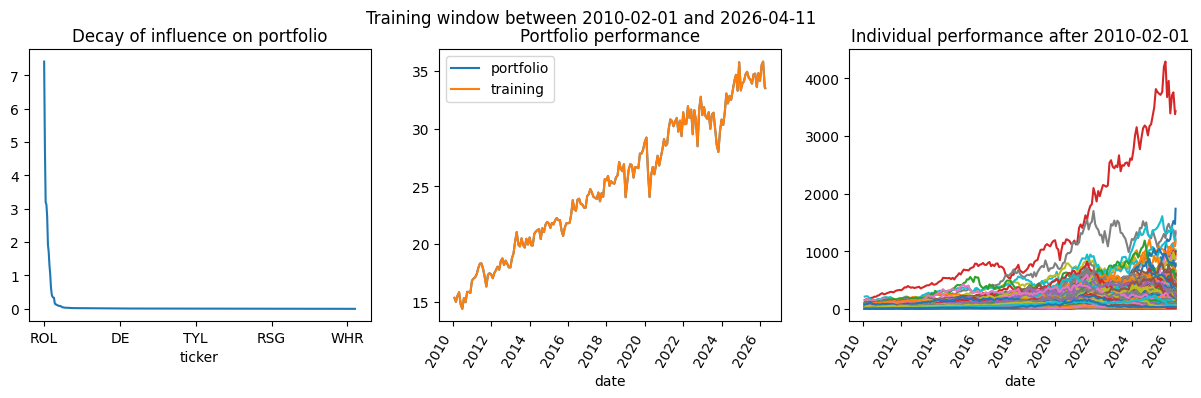

,2026
ROL,0.136684
FE,0.094354
HBAN,0.194946
T,0.118267
CPRT,0.084391
...,...
NKE,0.000032
EL,0.000018
CE,0.000021
FISV,0.000021


In [5]:
def plot_one_window(X, top_n=5):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    fig.suptitle(f"Training window between {X.index[0].date()} and {X.index[-1].date()}")
    
    estimator = PortfolioEstimator(verbose=False).fit(X)
    
    portfolio_composition = estimator.predict(X.iloc[-1]).sort_values(ascending=False) #At the last date of the given dataset
    portfolio_composition.plot(ax=ax[0], title='Decay of influence on portfolio')
    
    best_picks = portfolio_composition.head(top_n).index.to_list()
    
    portfolio_performance = estimator.predict(dataset)[best_picks].sum(axis='columns').rename('portfolio').to_frame()
    portfolio_performance['training'] = estimator.predict(X)[best_picks].sum(axis='columns')
    portfolio_performance.plot(ax=ax[1], rot=60, title='Portfolio performance',legend=True)
    
    dataset[dataset.index>=X.index.min()][best_picks].plot(ax=ax[2], rot=60,
                                                           title = f"Individual performance after {X.index[0].date()}",
                                                           legend = True if top_n<=10 else False)
    plt.show(fig)
    
    # We return the weights of the best picks so that we can show them all at once at the end.
    return estimator.weights_.rename(X.index[-1].year).loc[best_picks].to_frame()
    
plot_one_window(dataset, top_n=len(dataset.columns))

A better approach is to train for a fixed window size of months and then see how a portfolio of the top N most influential tickers performs both before the training period and most importantly, after it.

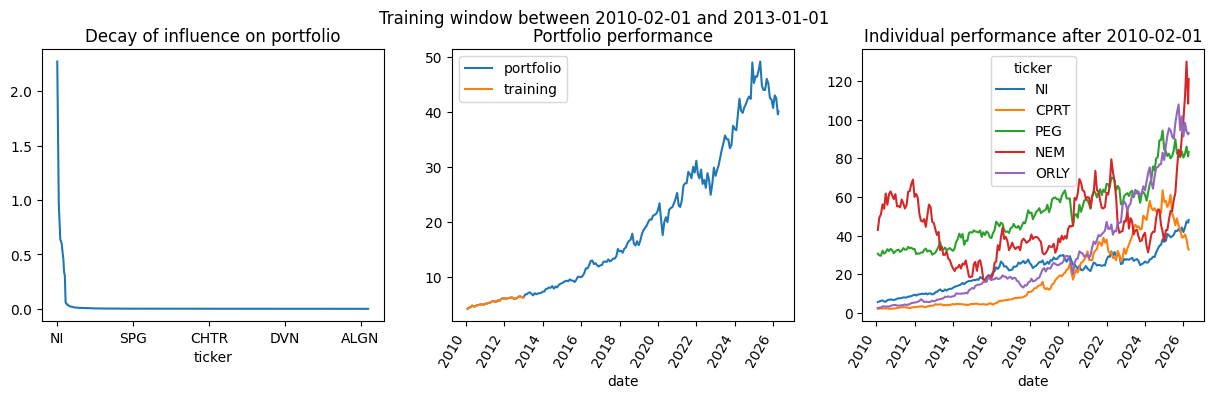

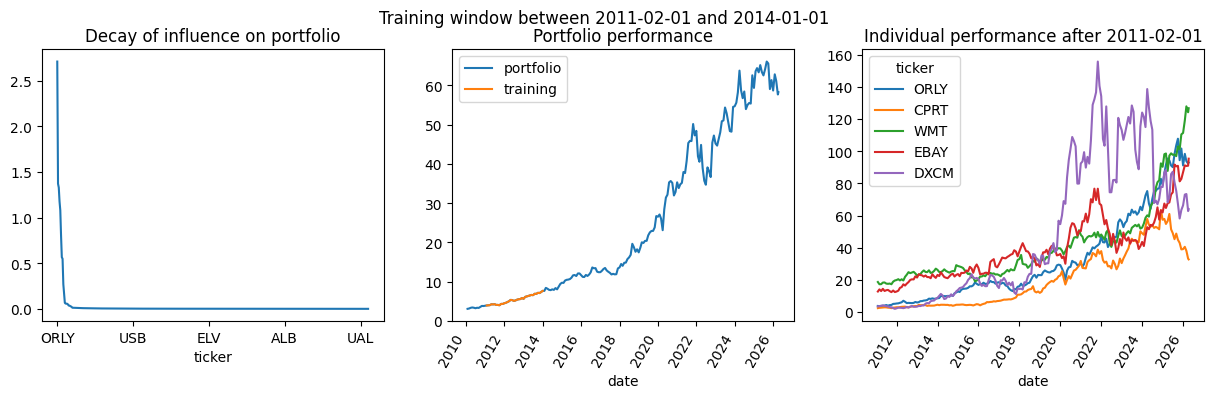

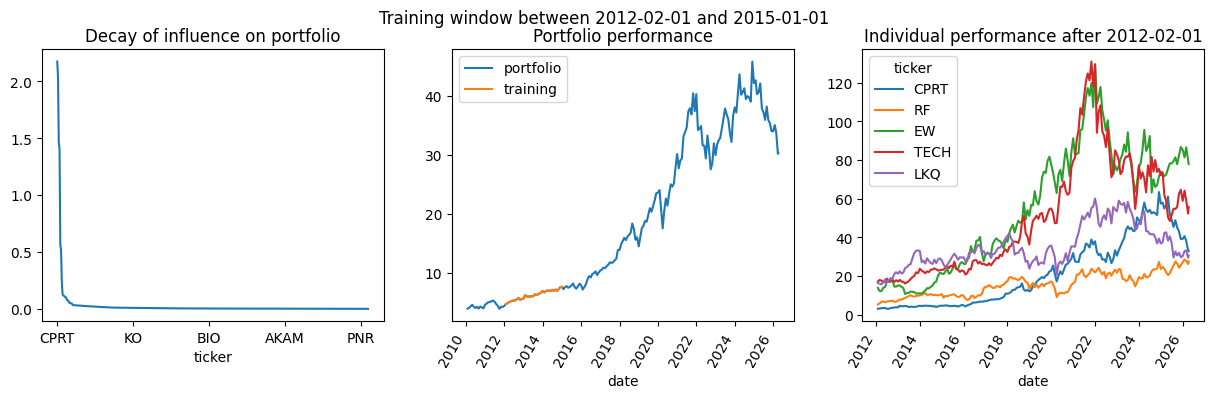

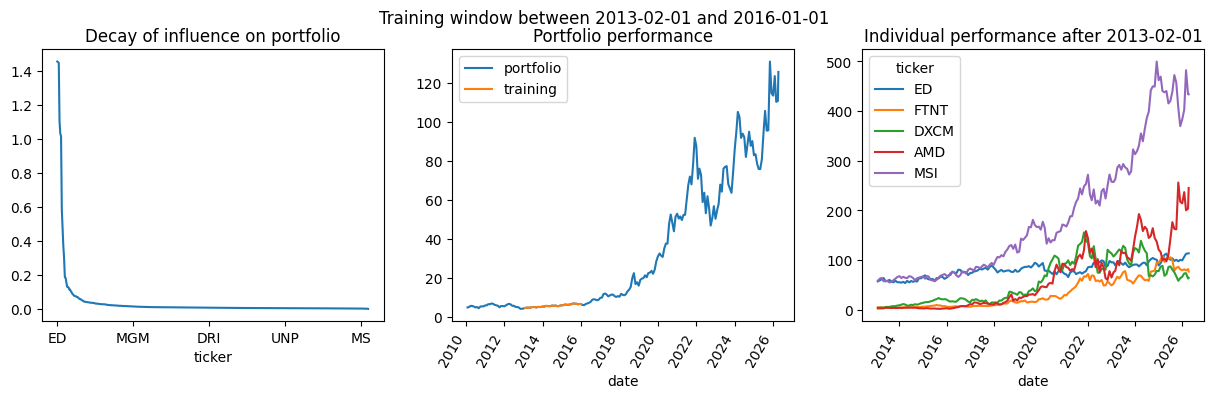

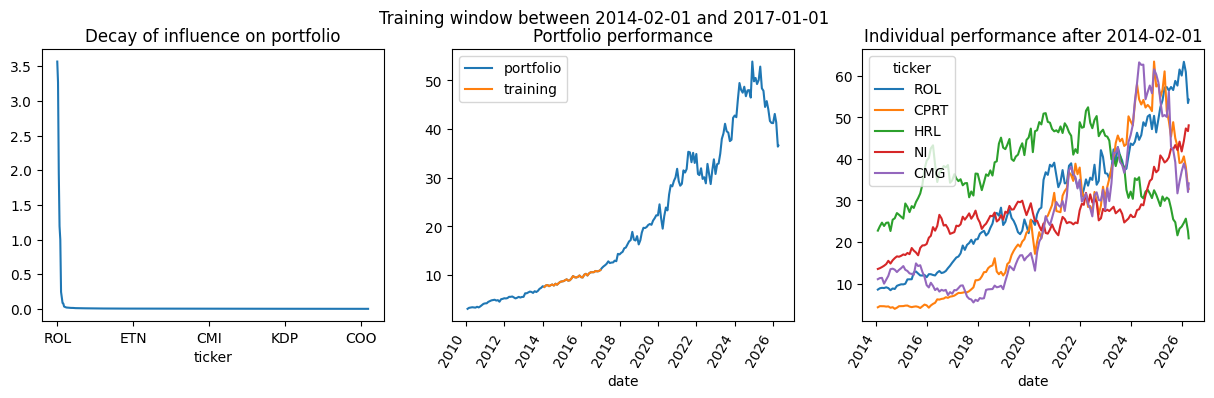

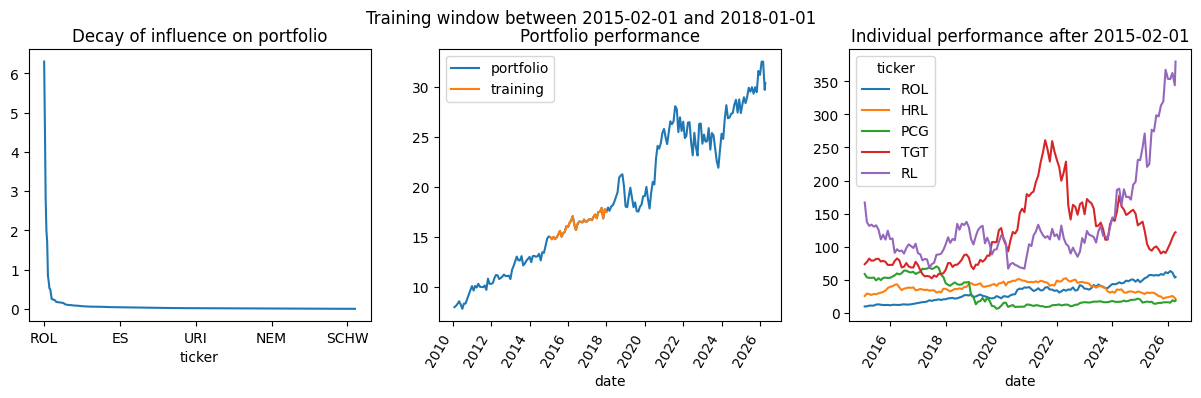

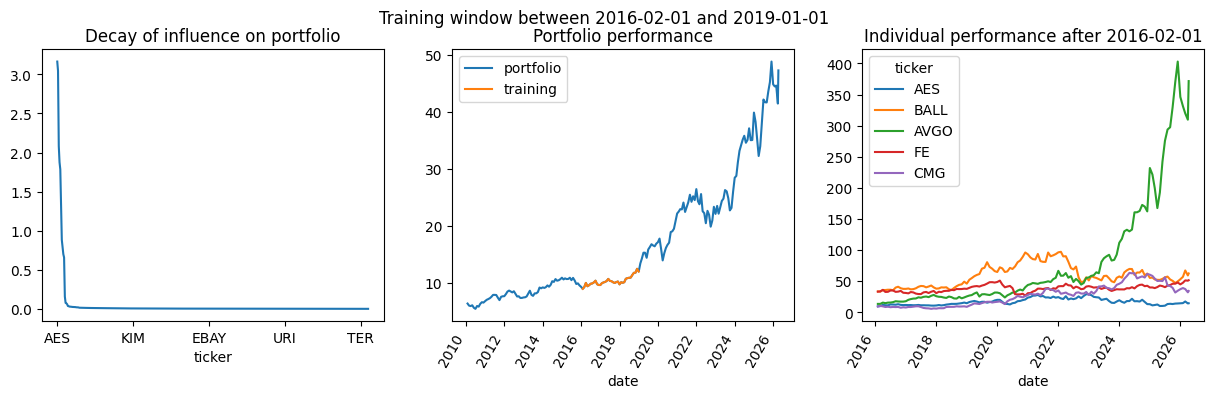

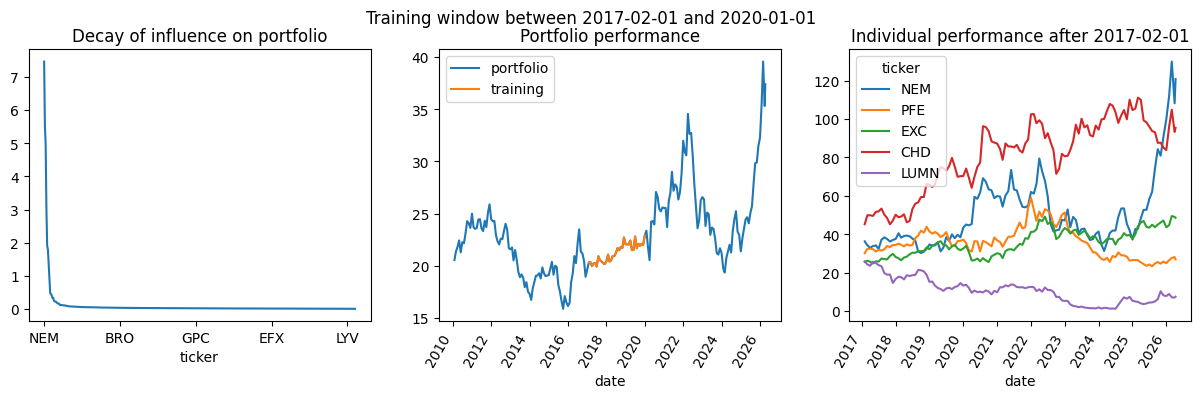

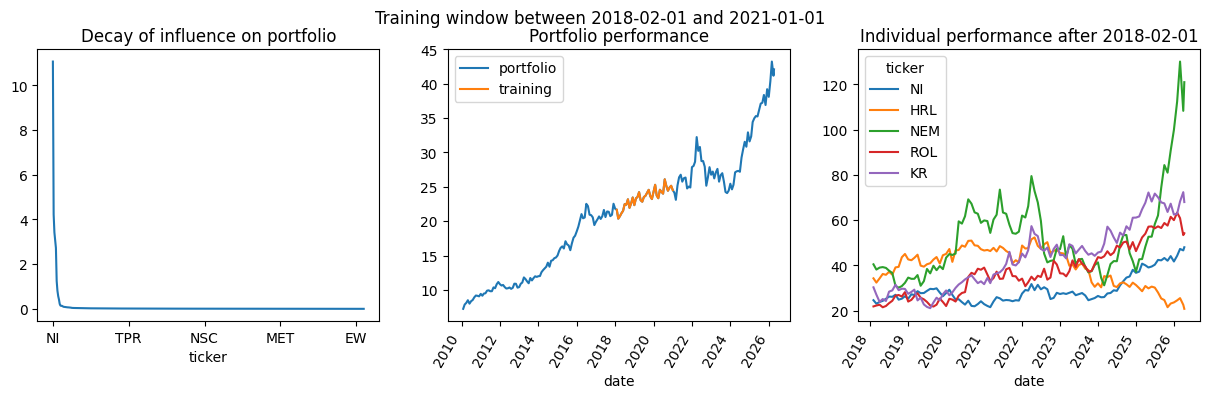

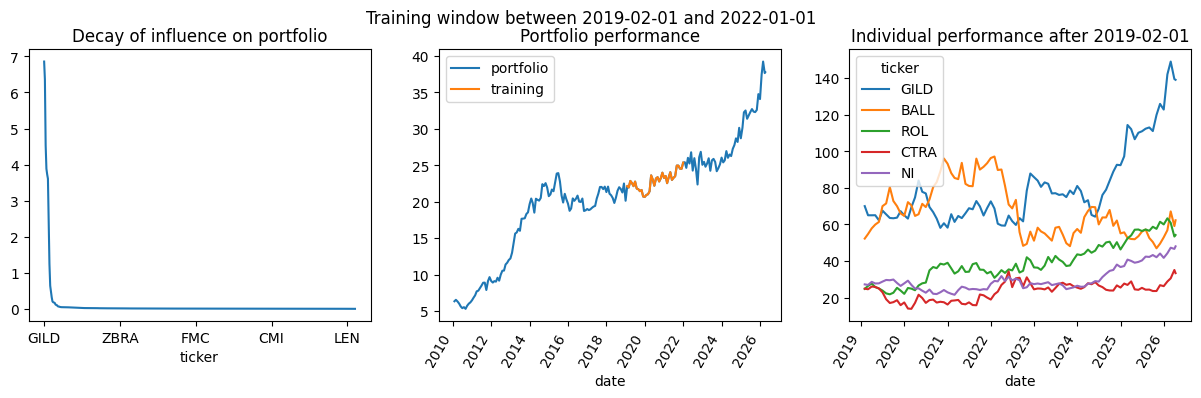

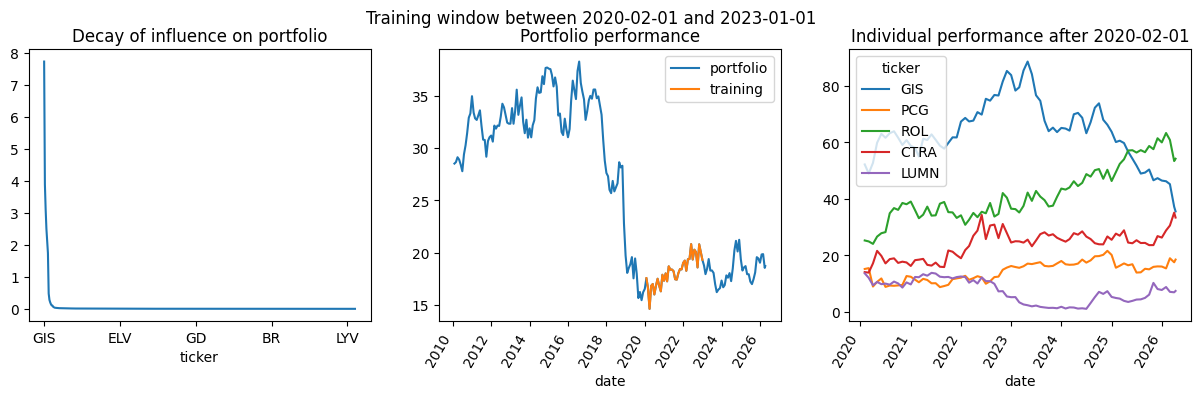

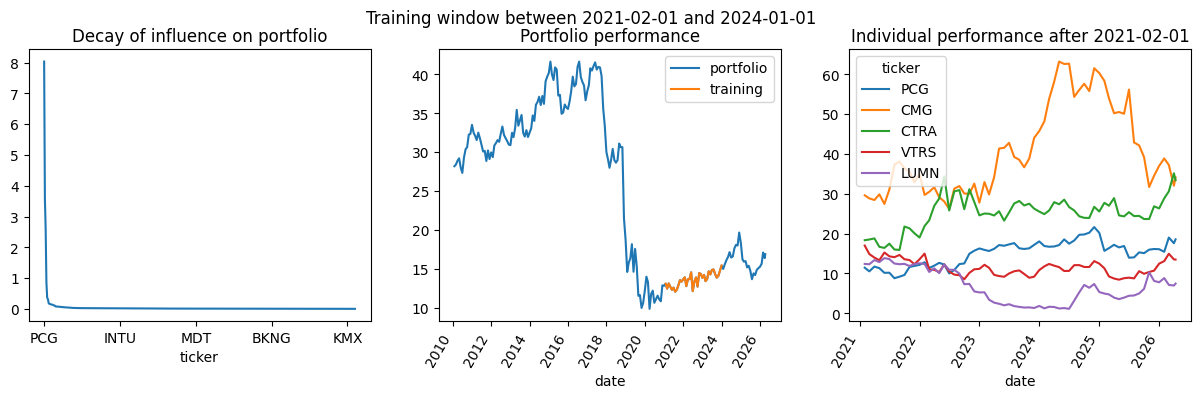

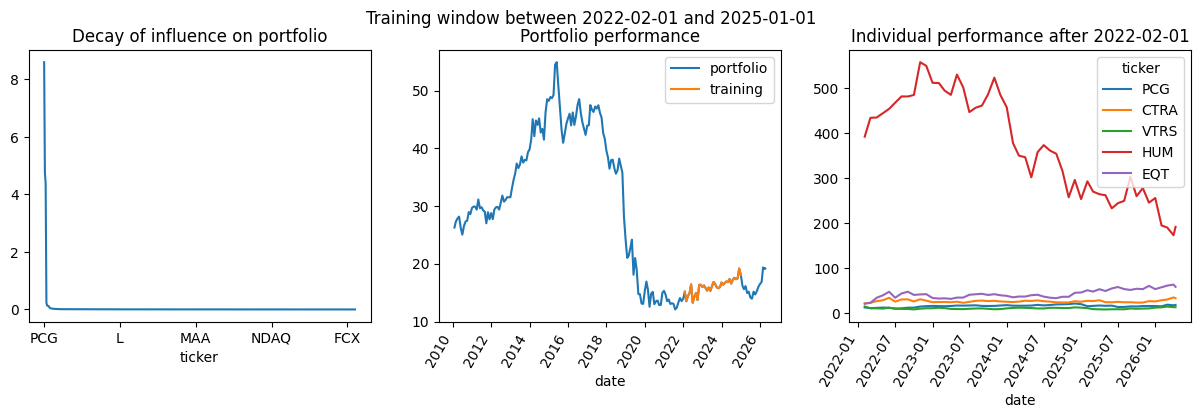

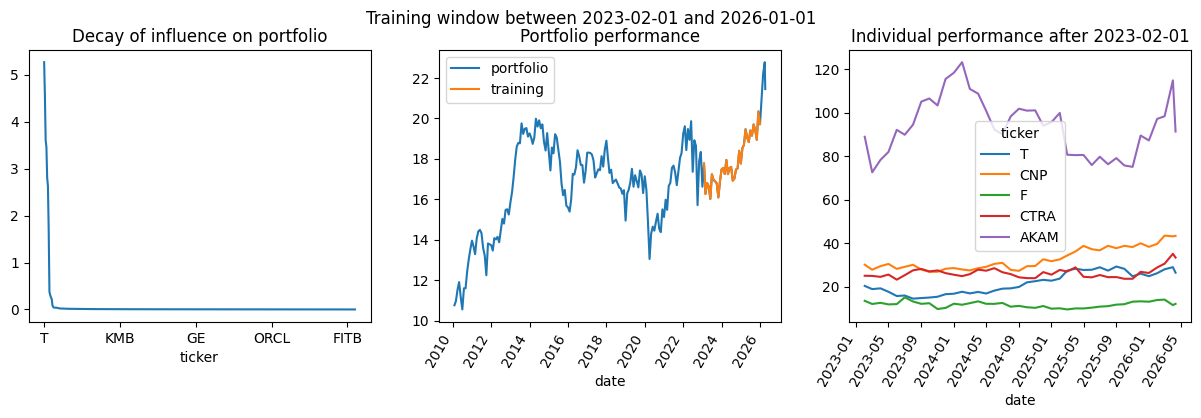

In [6]:
# A sliding window with length 3 years and step 1 year.
window_length = 36 #Months
all_weights = []
for window_start in range(0, 1+len(dataset)-window_length, 12):
    all_weights.append(plot_one_window(dataset.iloc[window_start : window_start+window_length]))
all_weights = pd.concat(all_weights, axis='columns')

Display the raw coefficients. Tickers that appear in more years are on top.

In [7]:
sort_order = all_weights.count(axis='columns').rename('count').reset_index().sort_values(
    by=['count','index'],ascending=[False,True])['index']

all_weights.loc[sort_order].style.format(na_rep='',precision=4)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
CTRA,,,,,,,,,,0.2045,0.1017,0.1021,0.1861,0.1316
ROL,,,,,0.2376,0.3045,,,0.0791,0.1326,0.0848,,,
CPRT,0.4362,0.2995,0.4766,,0.4713,,,,,,,,,
NI,0.2323,,,,0.0539,,,,0.4821,0.1350,,,,
PCG,,,,,,0.0627,,,,,0.2390,0.4456,0.4261,
CMG,,,,,0.1322,,0.2066,,,,,0.0779,,
HRL,,,,,0.0564,0.1286,,,0.0906,,,,,
LUMN,,,,,,,,0.1446,,,0.4071,0.1999,,
NEM,0.0174,,,,,,,0.1719,0.0571,,,,,
BALL,,,,,,,0.0662,,,0.0661,,,,


In [8]:
print('Done without errors.')

Done without errors.


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.